<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/13_tabular_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 13 — Tabular Data Augmentation

## What This Notebook Covers
Tabular data is the most common data type in industry — spreadsheets,
databases, sensor readings, financial data. Yet it receives the least
attention in augmentation research, partly because naive augmentation
can easily violate feature correlations and produce unrealistic samples.

Good tabular augmentation must:
- Respect correlations between features
- Stay within realistic feature value ranges
- Preserve class-discriminative patterns
- Handle mixed types (numerical + categorical)

**Techniques covered:**
- Gaussian noise injection
- Feature dropout (randomly zero out features)
- SMOTE — Synthetic Minority Over-sampling Technique
- ADASYN — Adaptive Synthetic Sampling
- Mixup for tabular data
- CutMix for tabular data
- Feature permutation within class
- GAN-based augmentation concept
- A/B test: baseline vs augmented training

**Dataset:** Breast Cancer Wisconsin (binary classification)
and a synthetic imbalanced dataset to demonstrate SMOTE.


In [1]:
!pip install imbalanced-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import random
import seaborn as sns

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 1. Load & Prepare Data


Dataset: Breast Cancer Wisconsin
Samples : 569
Features: 30
Classes : ['malignant' 'benign']  Counter({np.int64(1): 357, np.int64(0): 212})

Train: (455, 30), Test: (114, 30)
Feature range after scaling: [-2.72, 11.66]


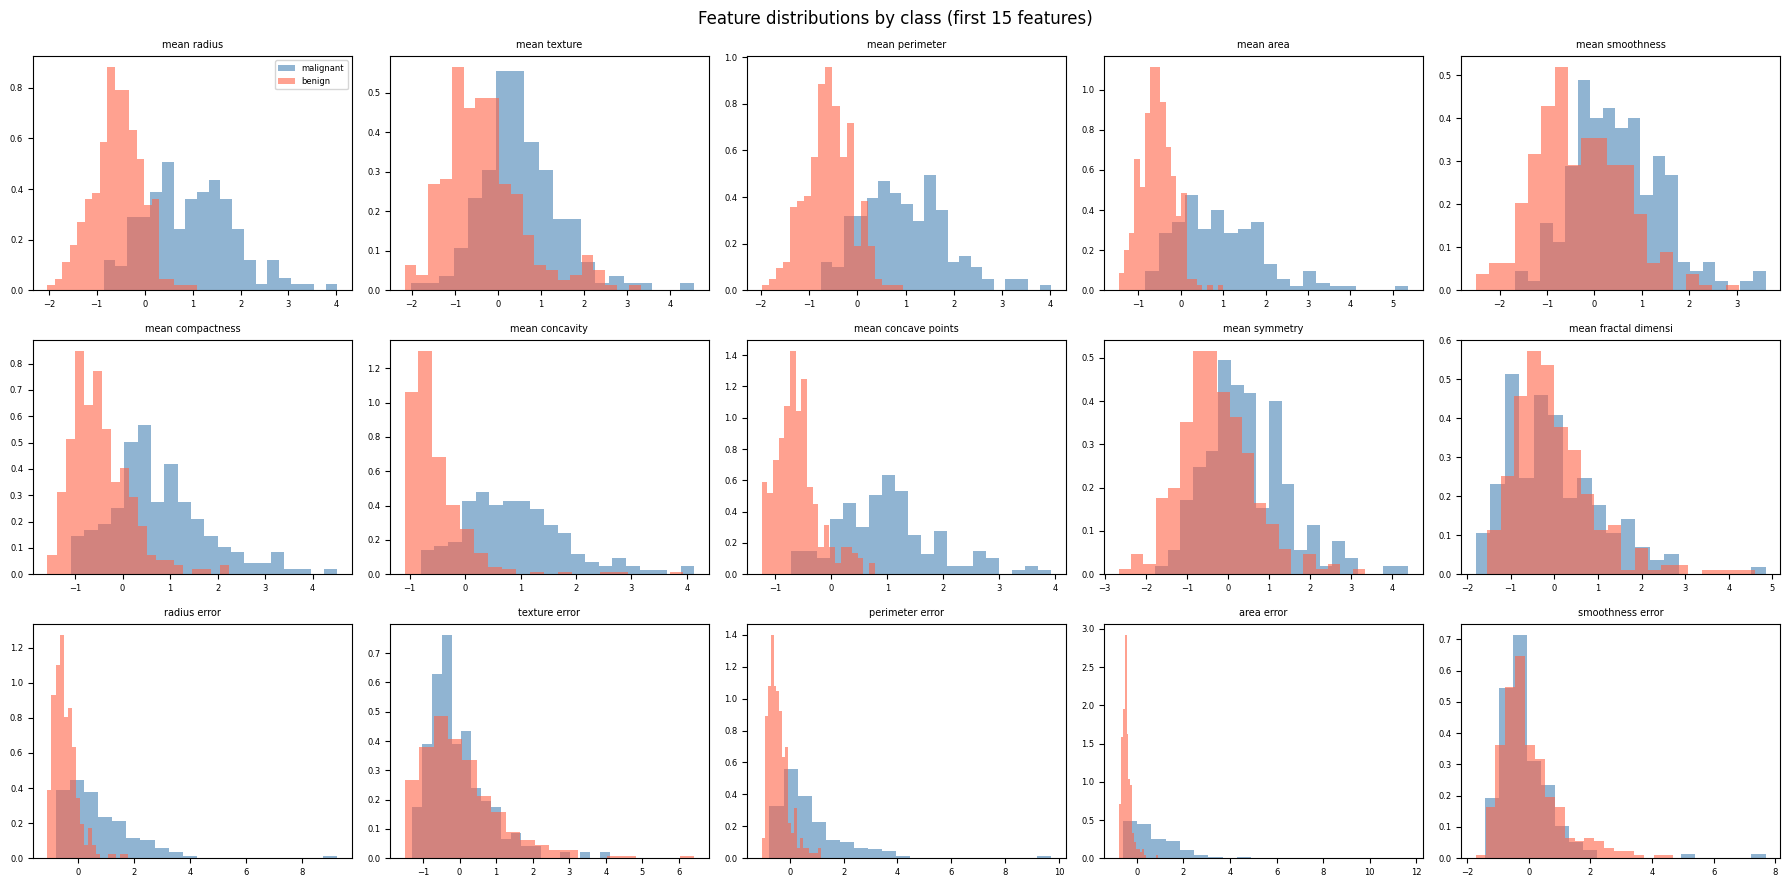

In [2]:
# Breast Cancer Wisconsin dataset
# 569 samples, 30 numerical features, 2 classes (malignant / benign)
data = load_breast_cancer()
X    = data.data.astype(np.float32)
y    = data.target.astype(np.int64)

feature_names = data.feature_names
class_names   = data.target_names

print(f'Dataset: Breast Cancer Wisconsin')
print(f'Samples : {X.shape[0]}')
print(f'Features: {X.shape[1]}')
print(f'Classes : {class_names}  {Counter(y)}')
print()

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features — CRITICAL for tabular augmentation
# Features must be on the same scale before adding noise or mixing
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Feature range after scaling: [{X_train.min():.2f}, {X_train.max():.2f}]')

# Show feature distributions
df = pd.DataFrame(X_train, columns=feature_names)
df['label'] = y_train

fig, axes = plt.subplots(3, 5, figsize=(18, 9))
for i, (ax, feat) in enumerate(zip(axes.flatten(), feature_names[:15])):
    ax.hist(df[df.label==0][feat], bins=20, alpha=0.6, color='steelblue',
            label=class_names[0], density=True)
    ax.hist(df[df.label==1][feat], bins=20, alpha=0.6, color='tomato',
            label=class_names[1], density=True)
    ax.set_title(feat[:20], fontsize=7)
    ax.set_xlabel('')
    ax.tick_params(labelsize=6)
    if i == 0:
        ax.legend(fontsize=6)
plt.suptitle('Feature distributions by class (first 15 features)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Gaussian Noise Injection

The simplest tabular augmentation: add small Gaussian noise to each feature.
After standardization, features have std=1, so sigma=0.05-0.1 adds
5-10% noise relative to the feature scale.

Key constraint: noise must be small enough that feature values remain
within a realistic range for the domain.


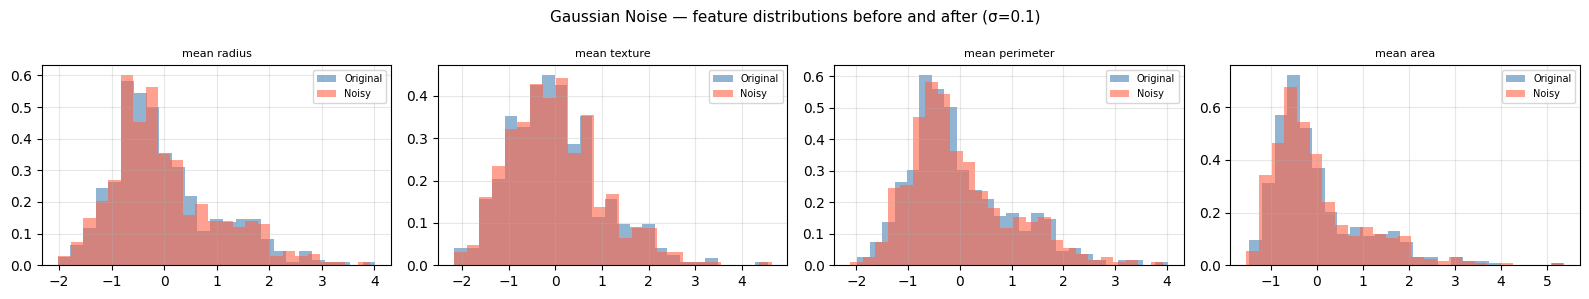

Key: distributions should be slightly wider but same shape.
Too much noise: distributions merge and classes become indistinguishable.


In [3]:
def gaussian_noise(X, sigma=0.05):
    """
    Add zero-mean Gaussian noise to each feature independently.
    After StandardScaler, features have std~1, so sigma=0.05 is 5% noise.
    """
    noise = np.random.randn(*X.shape).astype(np.float32) * sigma
    return X + noise


# Visualise effect on feature distributions
X_noisy = gaussian_noise(X_train, sigma=0.1)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.hist(X_train[:, i], bins=25, alpha=0.6, color='steelblue',
            label='Original', density=True)
    ax.hist(X_noisy[:, i],  bins=25, alpha=0.6, color='tomato',
            label='Noisy', density=True)
    ax.set_title(f'{feature_names[i][:18]}', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('Gaussian Noise — feature distributions before and after (σ=0.1)', fontsize=11)
plt.tight_layout()
plt.show()

print('Key: distributions should be slightly wider but same shape.')
print('Too much noise: distributions merge and classes become indistinguishable.')

## 3. Feature Dropout

Randomly set a fraction of features to zero (or their mean) during training.
Forces the model to not rely on any single feature — similar in spirit to
dropout on activations, but applied to input features.
Useful when some features may be missing at inference time.


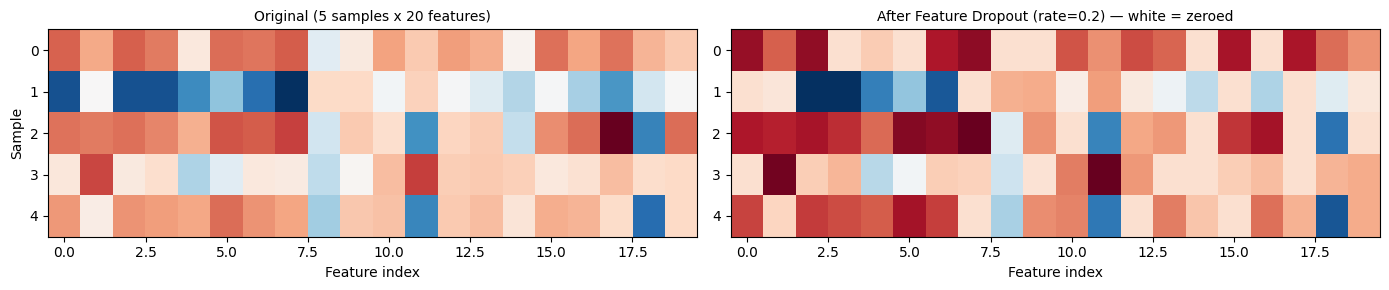

Features zeroed in 5x20 matrix: 20 / 100  (expect ~20)


In [4]:
def feature_dropout(X, drop_rate=0.1, fill_value=0.0):
    """
    Randomly zero out features for each sample independently.
    drop_rate: probability of zeroing each feature
    fill_value: what to fill with (0 = mean after StandardScaler)

    Each sample gets a different random mask — same sample may have
    different features dropped in different training steps.
    """
    mask = np.random.binomial(1, 1 - drop_rate,
                               size=X.shape).astype(np.float32)
    return X * mask + fill_value * (1 - mask)


# Demo: show which features get dropped for 5 samples
X_dropped = feature_dropout(X_train[:5], drop_rate=0.2)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(X_train[:5, :20], aspect='auto', cmap='RdBu')
axes[0].set_title('Original (5 samples x 20 features)', fontsize=10)
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Sample')

axes[1].imshow(X_dropped[:, :20], aspect='auto', cmap='RdBu')
axes[1].set_title('After Feature Dropout (rate=0.2) — white = zeroed', fontsize=10)
axes[1].set_xlabel('Feature index')

plt.tight_layout()
plt.show()

dropped_count = (X_dropped[:5, :20] == 0).sum()
print(f'Features zeroed in 5x20 matrix: {dropped_count} / 100  '
      f'(expect ~{int(5*20*0.2)})')

## 4. Tabular Mixup

Mixup for tabular data works identically to image Mixup:
blend two samples and their labels by a random lambda.

The key difference from image Mixup: with tabular data we use
`sparse_categorical_crossentropy` — we must convert to soft labels
or use KL divergence loss.

Here we implement both the feature blending and a soft-label loss.


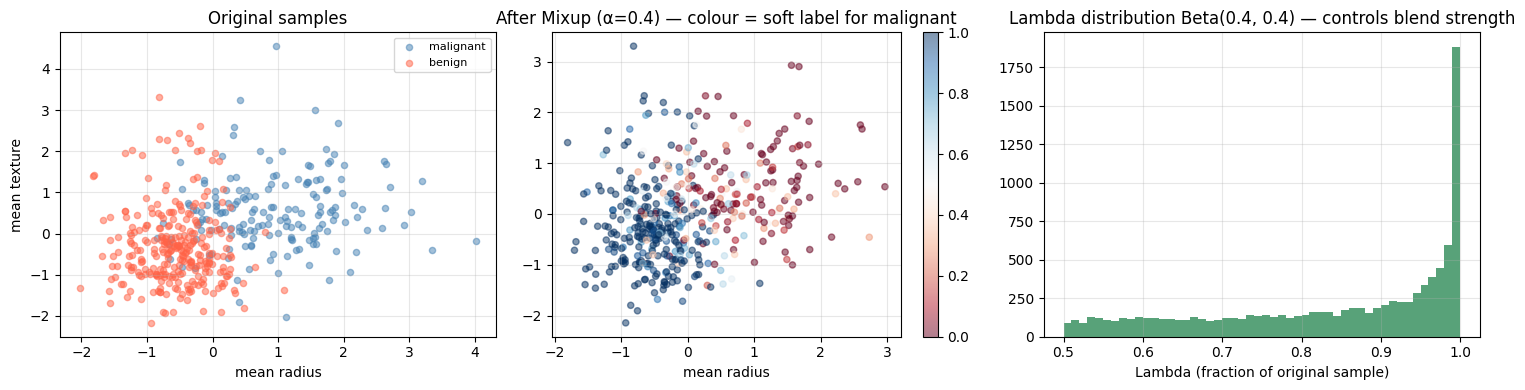

In [5]:
def tabular_mixup(X, y, alpha=0.2, n_classes=2):
    """
    Apply Mixup to a batch of tabular samples.

    For each sample, randomly select another sample and blend:
    x_mix = lam * x_i + (1 - lam) * x_j
    y_mix = lam * y_i + (1 - lam) * y_j  (soft labels)

    alpha: Beta distribution parameter controlling blend strength
           alpha=0.2: mostly original with small blend
           alpha=1.0: uniform blend
    """
    n = len(X)
    # Sample lambda from Beta distribution
    lam = np.random.beta(alpha, alpha, size=n).astype(np.float32)
    lam = np.maximum(lam, 1 - lam)   # ensure lam >= 0.5 (original dominates)

    # Random permutation for pairing
    perm = np.random.permutation(n)

    X_mix = (lam[:, None] * X + (1 - lam[:, None]) * X[perm])

    # One-hot encode labels for soft mixing
    y_oh   = np.eye(n_classes)[y].astype(np.float32)
    y_mix  = lam[:, None] * y_oh + (1 - lam[:, None]) * y_oh[perm]

    return X_mix.astype(np.float32), y_mix


# Visualise the blending effect on 2 features
X_mix, y_mix = tabular_mixup(X_train, y_train, alpha=0.4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter of first 2 features — original
for cls, color, name in [(0, 'steelblue', class_names[0]),
                           (1, 'tomato',    class_names[1])]:
    mask = y_train == cls
    axes[0].scatter(X_train[mask, 0], X_train[mask, 1],
                    alpha=0.5, color=color, s=20, label=name)
axes[0].set_title('Original samples')
axes[0].set_xlabel(feature_names[0][:20])
axes[0].set_ylabel(feature_names[1][:20])
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Scatter after Mixup — colour by soft label
sc = axes[1].scatter(X_mix[:, 0], X_mix[:, 1],
                      c=y_mix[:, 1], cmap='RdBu', alpha=0.5, s=20)
plt.colorbar(sc, ax=axes[1])
axes[1].set_title('After Mixup (α=0.4) — colour = soft label for malignant')
axes[1].set_xlabel(feature_names[0][:20])
axes[1].grid(True, alpha=0.3)

# Distribution of lambda values
lambdas = np.random.beta(0.4, 0.4, size=10000)
lambdas = np.maximum(lambdas, 1 - lambdas)
axes[2].hist(lambdas, bins=50, color='seagreen', alpha=0.8)
axes[2].set_title('Lambda distribution Beta(0.4, 0.4) — controls blend strength')
axes[2].set_xlabel('Lambda (fraction of original sample)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Tabular CutMix

Instead of blending all features, CutMix for tabular data randomly
selects a subset of features from sample A and the rest from sample B.
Labels are mixed proportionally to the fraction of features taken from each.


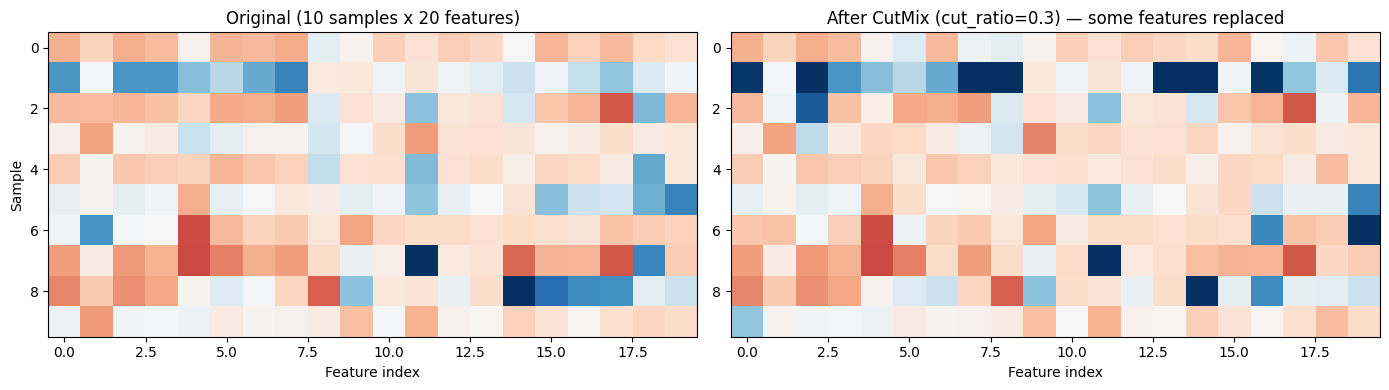

Soft label distribution after CutMix:
  Pure class 0: 14.73%
  Pure class 1: 40.00%
  Mixed labels: 45.27%


In [6]:
def tabular_cutmix(X, y, n_classes=2, cut_ratio=0.5):
    """
    For each sample, take a random subset of features from another sample.
    Label is mixed proportionally to the fraction of features taken.

    cut_ratio: expected fraction of features to take from the second sample
    """
    n, n_feats = X.shape
    perm       = np.random.permutation(n)

    X_cut  = X.copy()
    y_oh   = np.eye(n_classes)[y].astype(np.float32)
    y_cut  = y_oh.copy()

    for i in range(n):
        # Random binary mask: which features come from sample perm[i]
        mask = np.random.binomial(1, cut_ratio, size=n_feats).astype(bool)
        lam  = 1 - mask.mean()   # fraction from original sample

        X_cut[i, mask]  = X[perm[i], mask]
        y_cut[i]        = lam * y_oh[i] + (1 - lam) * y_oh[perm[i]]

    return X_cut.astype(np.float32), y_cut


X_cut, y_cut = tabular_cutmix(X_train, y_train, cut_ratio=0.3)

# Visualise feature-level mixing
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(X_train[:10, :20], aspect='auto', cmap='RdBu',
               vmin=-3, vmax=3)
axes[0].set_title('Original (10 samples x 20 features)')
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Sample')

axes[1].imshow(X_cut[:10, :20], aspect='auto', cmap='RdBu',
               vmin=-3, vmax=3)
axes[1].set_title('After CutMix (cut_ratio=0.3) — some features replaced')
axes[1].set_xlabel('Feature index')

plt.tight_layout()
plt.show()

print('Soft label distribution after CutMix:')
print(f'  Pure class 0: {(y_cut[:, 0] == 1.0).mean():.2%}')
print(f'  Pure class 1: {(y_cut[:, 1] == 1.0).mean():.2%}')
print(f'  Mixed labels: {((y_cut[:, 0] > 0) & (y_cut[:, 0] < 1)).mean():.2%}')

## 6. SMOTE — Synthetic Minority Over-sampling

SMOTE is the most widely used technique for **class imbalance**.
Instead of duplicating minority class samples (which overfits),
SMOTE synthesizes NEW samples by interpolating between existing
minority class neighbors.

Algorithm:
1. For each minority sample, find k nearest neighbors in the minority class
2. Pick a random neighbor
3. Create synthetic sample: original + random * (neighbor - original)

The synthetic sample lies on the line segment between two real samples.


In [7]:
# Create a strongly imbalanced dataset for SMOTE demo
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.9, 0.1],   # 90% class 0, 10% class 1
    random_state=42
)
X_imb = X_imb.astype(np.float32)

print('Before SMOTE:')
print(f'  Class distribution: {Counter(y_imb)}')
print(f'  Imbalance ratio: {Counter(y_imb)[0] / Counter(y_imb)[1]:.1f}:1')

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_imb, y_imb)

print('\nAfter SMOTE:')
print(f'  Class distribution: {Counter(y_smote)}')
print(f'  Imbalance ratio: {Counter(y_smote)[0] / Counter(y_smote)[1]:.1f}:1')
print(f'  New samples generated: {len(X_smote) - len(X_imb)}')

Before SMOTE:
  Class distribution: Counter({np.int64(0): 896, np.int64(1): 104})
  Imbalance ratio: 8.6:1

After SMOTE:
  Class distribution: Counter({np.int64(0): 896, np.int64(1): 896})
  Imbalance ratio: 1.0:1
  New samples generated: 792


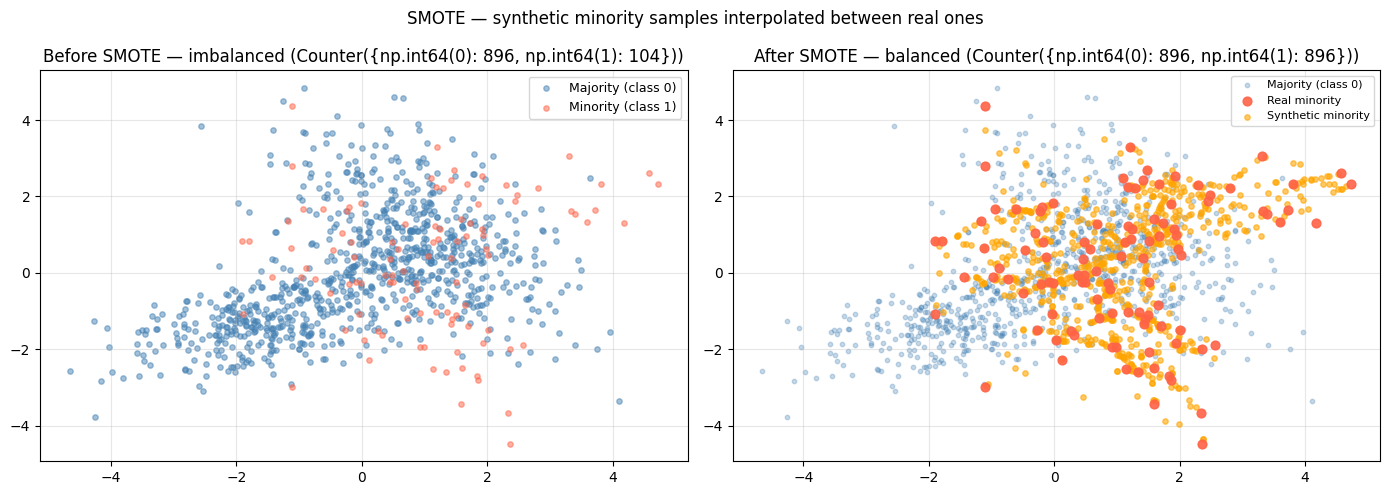

In [9]:
import numpy as np
# Visualise SMOTE in 2D (first 2 features)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color, name in [(0, 'steelblue', 'Majority (class 0)'),
                           (1, 'tomato',    'Minority (class 1)')]:
    mask = y_imb == cls
    axes[0].scatter(X_imb[mask, 0], X_imb[mask, 1],
                    alpha=0.5, color=color, s=15, label=name)
axes[0].set_title(f'Before SMOTE — imbalanced ({Counter(y_imb)})')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Mark real vs synthetic minority samples
n_orig_minority = (y_imb == 1).sum()
for cls, color, name in [(0, 'steelblue', 'Majority (class 0)')]:
    mask = y_smote == cls
    axes[1].scatter(X_smote[mask, 0], X_smote[mask, 1],
                    alpha=0.3, color=color, s=10, label=name)

# Real minority samples
real_minority_X_smote = X_smote[:len(X_imb)][y_imb == 1]
axes[1].scatter(real_minority_X_smote[:, 0],
                real_minority_X_smote[:, 1],
                color='tomato', s=40, alpha=0.9, zorder=5, label='Real minority')

# Synthetic minority samples
synth_mask = np.zeros(len(X_smote), dtype=bool)
synth_mask[len(X_imb):] = True
synth_mask &= (y_smote == 1)
axes[1].scatter(X_smote[synth_mask, 0], X_smote[synth_mask, 1],
                color='orange', s=15, alpha=0.6, zorder=4, label='Synthetic minority')

axes[1].set_title(f'After SMOTE — balanced ({Counter(y_smote)})')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('SMOTE — synthetic minority samples interpolated between real ones', fontsize=12)
plt.tight_layout()
plt.show()

## 7. ADASYN — Adaptive Synthetic Sampling

ADASYN extends SMOTE by generating MORE synthetic samples in
regions where the minority class is harder to learn (near the
decision boundary) and fewer in easy regions.

This focuses augmentation effort where it is most needed.


SMOTE  — balanced to: Counter({np.int64(0): 896, np.int64(1): 896})
ADASYN — balanced to: Counter({np.int64(0): 896, np.int64(1): 878})

ADASYN generates slightly more samples in hard regions,
so the final count may differ slightly from SMOTE.


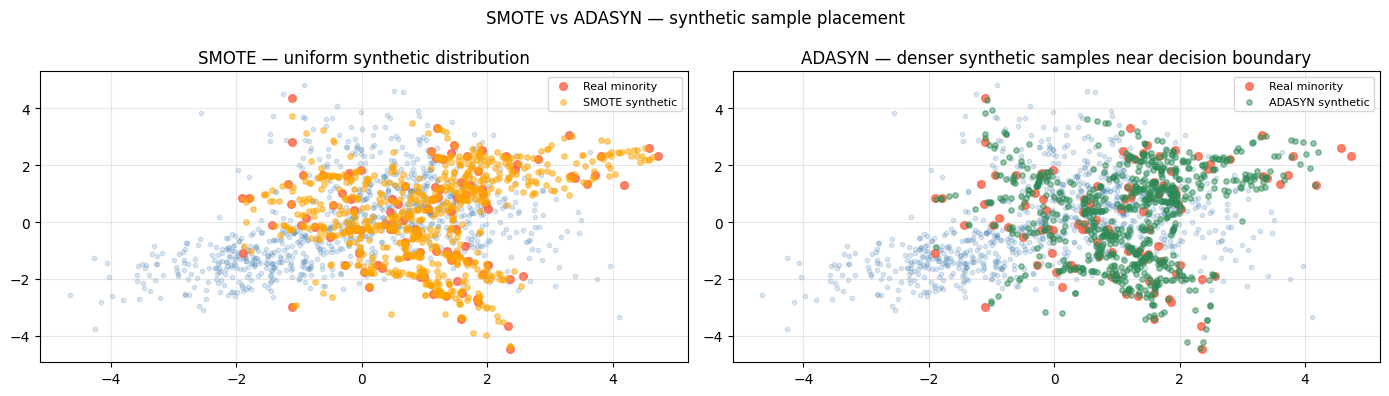

In [10]:
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_ada, y_ada = adasyn.fit_resample(X_imb, y_imb)

print('SMOTE  — balanced to:', Counter(y_smote))
print('ADASYN — balanced to:', Counter(y_ada))
print()
print('ADASYN generates slightly more samples in hard regions,')
print('so the final count may differ slightly from SMOTE.')

# Compare SMOTE vs ADASYN synthetic distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# SMOTE synthetic positions
smote_synth = X_smote[len(X_imb):]
smote_y     = y_smote[len(X_imb):]
axes[0].scatter(X_imb[y_imb==0, 0], X_imb[y_imb==0, 1],
                alpha=0.2, s=10, color='steelblue')
axes[0].scatter(X_imb[y_imb==1, 0], X_imb[y_imb==1, 1],
                alpha=0.8, s=30, color='tomato', label='Real minority')
axes[0].scatter(smote_synth[:, 0], smote_synth[:, 1],
                alpha=0.5, s=15, color='orange', label='SMOTE synthetic')
axes[0].set_title('SMOTE — uniform synthetic distribution')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# ADASYN synthetic positions
ada_synth = X_ada[len(X_imb):]
axes[1].scatter(X_imb[y_imb==0, 0], X_imb[y_imb==0, 1],
                alpha=0.2, s=10, color='steelblue')
axes[1].scatter(X_imb[y_imb==1, 0], X_imb[y_imb==1, 1],
                alpha=0.8, s=30, color='tomato', label='Real minority')
axes[1].scatter(ada_synth[:, 0], ada_synth[:, 1],
                alpha=0.5, s=15, color='seagreen', label='ADASYN synthetic')
axes[1].set_title('ADASYN — denser synthetic samples near decision boundary')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('SMOTE vs ADASYN — synthetic sample placement', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Full Augmentation Pipeline for Training


In [11]:
def augment_tabular(x, sigma_noise=0.05, drop_rate=0.05):
    """
    On-the-fly tabular augmentation for a single sample.
    Applied in Dataset.__getitem__ during training.

    Combines Gaussian noise and feature dropout.
    Mixup/CutMix are applied at the batch level (see training loop).
    """
    x = x.copy()

    # Gaussian noise
    if random.random() < 0.6:
        x += np.random.randn(*x.shape).astype(np.float32) * sigma_noise

    # Feature dropout
    if random.random() < 0.4:
        mask = np.random.binomial(1, 1 - drop_rate, size=x.shape).astype(np.float32)
        x *= mask

    return x


class TabularDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X       = X.astype(np.float32)
        self.y       = y.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        y = self.y[idx]
        if self.augment:
            x = augment_tabular(x)
        return torch.tensor(x), torch.tensor(y)


BATCH_SIZE = 32

train_ds_base = TabularDataset(X_train, y_train, augment=False)
train_ds_aug  = TabularDataset(X_train, y_train, augment=True)
test_ds       = TabularDataset(X_test,  y_test,  augment=False)

train_loader_base = DataLoader(train_ds_base, batch_size=BATCH_SIZE, shuffle=True)
train_loader_aug  = DataLoader(train_ds_aug,  batch_size=BATCH_SIZE, shuffle=True)
test_loader       = DataLoader(test_ds,        batch_size=BATCH_SIZE, shuffle=False)

print('Datasets ready.')
X_b, y_b = next(iter(train_loader_aug))
print(f'Batch shape: {X_b.shape}, labels: {y_b.shape}')

Datasets ready.
Batch shape: torch.Size([32, 30]), labels: torch.Size([32])


## 9. Tabular Classifier — MLP with BatchNorm


In [12]:
class TabularMLP(nn.Module):
    """
    Multi-layer perceptron for tabular binary classification.
    Uses BatchNorm after each linear layer for training stability.
    BatchNorm is particularly effective for tabular data because
    features can have very different scales even after StandardScaler.
    """
    def __init__(self, n_features=30, n_classes=2,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers  = []
        in_dim  = n_features

        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            in_dim = h

        layers.append(nn.Linear(in_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_model():
    return TabularMLP(
        n_features=X_train.shape[1],
        n_classes=2,
        hidden_dims=(256, 128, 64),
        dropout=0.3
    ).to(device)

test_m = make_model()
print(f'Output shape: {test_m(X_b.to(device)).shape}  (expect [32, 2])')
print(f'Parameters  : {sum(p.numel() for p in test_m.parameters()):,}')

Output shape: torch.Size([32, 2])  (expect [32, 2])
Parameters  : 50,114


## 10. A/B Test: No Augmentation vs Augmented


In [13]:
def train_tabular(train_loader, label='', epochs=50, use_mixup=False):
    torch.manual_seed(42)
    model     = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    hist     = {'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        correct = total = 0

        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)

            if use_mixup and random.random() < 0.5:
                # Batch-level Mixup
                lam  = np.random.beta(0.4, 0.4)
                lam  = max(lam, 1 - lam)
                perm = torch.randperm(X_b.size(0))
                X_mix = lam * X_b + (1 - lam) * X_b[perm]

                optimizer.zero_grad()
                out  = model(X_mix)
                loss = (lam * criterion(out, y_b)
                        + (1 - lam) * criterion(out, y_b[perm]))
            else:
                optimizer.zero_grad()
                out  = model(X_b)
                loss = criterion(out, y_b)

            loss.backward()
            optimizer.step()
            correct += (out.detach().argmax(1) == y_b).sum().item()
            total   += y_b.size(0)

        train_acc = correct / total

        model.eval()
        correct = total = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b).argmax(1)
                correct += (preds == y_b).sum().item()
                total   += y_b.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_b.cpu().numpy())

        test_acc = correct / total
        best_acc = max(best_acc, test_acc)

        scheduler.step()
        hist['train_acc'].append(train_acc)
        hist['test_acc'].append(test_acc)

        if (epoch + 1) % 10 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | '
                  f'train={train_acc:.4f} | test={test_acc:.4f}')

    print(f'[{label}] Best test accuracy: {best_acc:.4f}\n')
    return hist, best_acc, all_preds, all_labels


print('Training baseline (no augmentation)...')
hist_base, acc_base, preds_base, labels_base = train_tabular(
    train_loader_base, 'Baseline', epochs=50, use_mixup=False
)

print('Training with noise + dropout augmentation...')
hist_aug, acc_aug, preds_aug, labels_aug = train_tabular(
    train_loader_aug, 'Noise+Dropout', epochs=50, use_mixup=False
)

print('Training with noise + dropout + Mixup...')
hist_mix, acc_mix, preds_mix, labels_mix = train_tabular(
    train_loader_aug, 'Noise+Dropout+Mixup', epochs=50, use_mixup=True
)

Training baseline (no augmentation)...
[Baseline] Epoch 10 | train=0.9736 | test=0.9561
[Baseline] Epoch 20 | train=0.9604 | test=0.9825
[Baseline] Epoch 30 | train=0.9802 | test=0.9737
[Baseline] Epoch 40 | train=0.9846 | test=0.9912
[Baseline] Epoch 50 | train=0.9868 | test=0.9912
[Baseline] Best test accuracy: 0.9912

Training with noise + dropout augmentation...
[Noise+Dropout] Epoch 10 | train=0.9648 | test=0.9561
[Noise+Dropout] Epoch 20 | train=0.9560 | test=0.9825
[Noise+Dropout] Epoch 30 | train=0.9824 | test=0.9649
[Noise+Dropout] Epoch 40 | train=0.9758 | test=0.9825
[Noise+Dropout] Epoch 50 | train=0.9824 | test=0.9825
[Noise+Dropout] Best test accuracy: 0.9912

Training with noise + dropout + Mixup...
[Noise+Dropout+Mixup] Epoch 10 | train=0.9451 | test=0.9825
[Noise+Dropout+Mixup] Epoch 20 | train=0.9648 | test=0.9737
[Noise+Dropout+Mixup] Epoch 30 | train=0.9407 | test=0.9912
[Noise+Dropout+Mixup] Epoch 40 | train=0.9560 | test=0.9912
[Noise+Dropout+Mixup] Epoch 50 | tra

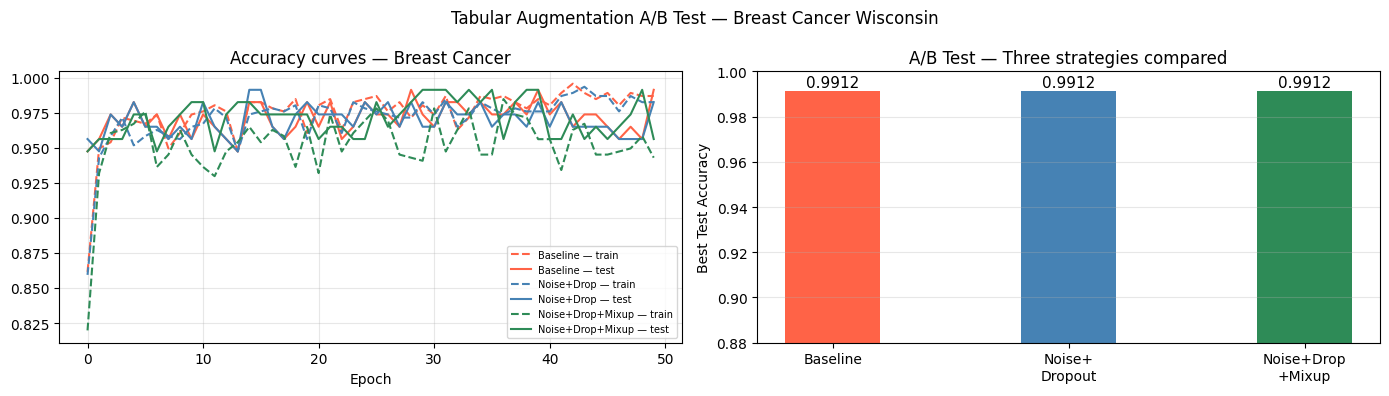

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_base['train_acc'], '--', color='tomato',    label='Baseline — train')
axes[0].plot(hist_base['test_acc'],        color='tomato',    label='Baseline — test')
axes[0].plot(hist_aug['train_acc'],  '--', color='steelblue', label='Noise+Drop — train')
axes[0].plot(hist_aug['test_acc'],         color='steelblue', label='Noise+Drop — test')
axes[0].plot(hist_mix['train_acc'],  '--', color='seagreen',  label='Noise+Drop+Mixup — train')
axes[0].plot(hist_mix['test_acc'],         color='seagreen',  label='Noise+Drop+Mixup — test')
axes[0].set_title('Accuracy curves — Breast Cancer')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(
    ['Baseline', 'Noise+\nDropout', 'Noise+Drop\n+Mixup'],
    [acc_base, acc_aug, acc_mix],
    color=['tomato', 'steelblue', 'seagreen'],
    width=0.4
)
for bar, acc in zip(bars, [acc_base, acc_aug, acc_mix]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{acc:.4f}', ha='center', fontsize=11
    )
axes[1].set_ylim(0.88, 1.0)
axes[1].set_ylabel('Best Test Accuracy')
axes[1].set_title('A/B Test — Three strategies compared')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Tabular Augmentation A/B Test — Breast Cancer Wisconsin', fontsize=12)
plt.tight_layout()
plt.show()

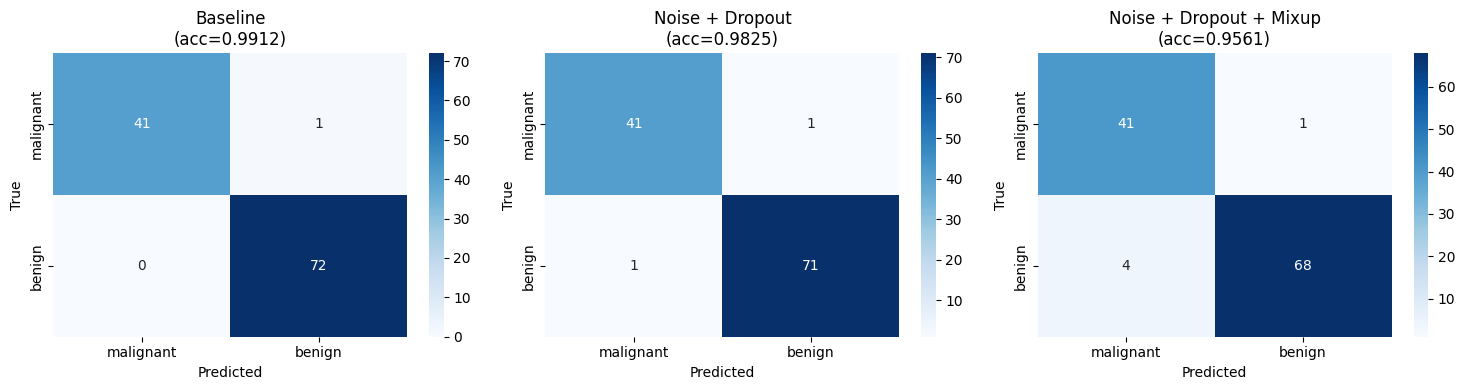

In [15]:
# Confusion matrix comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Baseline', 'Noise + Dropout', 'Noise + Dropout + Mixup']
all_results = [(preds_base, labels_base), (preds_aug, labels_aug), (preds_mix, labels_mix)]

for ax, (preds, labels), title in zip(axes, all_results, titles):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    acc = (np.array(preds) == np.array(labels)).mean()
    ax.set_title(f'{title}\n(acc={acc:.4f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

---
## Summary

### Technique Reference

| Technique | Type | Best for |
|---|---|---|
| Gaussian noise | On-the-fly | General regularization, sensor data |
| Feature dropout | On-the-fly | Missing-at-inference robustness |
| Tabular Mixup | Batch-level | General regularization, soft labels |
| Tabular CutMix | Batch-level | Feature-level mixing |
| SMOTE | Offline | Class imbalance — minority class |
| ADASYN | Offline | Class imbalance — focuses on hard samples |

### Decision Guide
- **Balanced classes** -> Gaussian noise + feature dropout + Mixup
- **Imbalanced classes** -> SMOTE or ADASYN first, then noise augmentation
- **Features may be missing at inference** -> feature dropout during training
- **Highly correlated features** -> be careful with Mixup; prefer noise only

### Critical Rule
Always standardize features before augmentation.
Without StandardScaler, noise magnitude is inconsistent across features
and SMOTE interpolation is dominated by high-variance features.

**Next: Notebook 14** — Speech Augmentation
